<a href="https://colab.research.google.com/github/grasht/grashaw_GAN_research_project/blob/main/Main_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#%pip install torch matplotlib

In [2]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.6 MB/s eta 0:00:00


In [ ]:
#!pip install table_evaluator

#Imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive
import os
from ctgan import CTGAN
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import ks_2samp
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

#Mount Drive

In [4]:
#!rm -rf /content/drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
base_path = "/content/drive/MyDrive/datasets/vehicle_sales"

!ls

drive  sample_data


#CTGAN on Vehicle Sales

#Import The Data

In [10]:
def handle_missing_continuous(df_in, continuous_cols, strategy="median"):
    df = df_in.copy()

    for col in continuous_cols:
        # 1. Create missing indicator
        df[f"{col}_missing"] = df[col].isna().astype(int)

        # 2. Impute values
        if strategy == "median":
            fill_value = df[col].median()
        elif strategy == "mean":
            fill_value = df[col].mean()
        elif strategy == "zero":
            fill_value = 0
        else:
            raise ValueError("Unsupported strategy")

        df[col] = df[col].fillna(fill_value)

    return df

In [5]:
vs_df = pd.read_csv(base_path+"/train.csv")
print(vs_df.head())
print(vs_df.shape)

   year      make       model         trim       body transmission  \
0  2010  Chrysler  PT Cruiser      Classic      Wagon    automatic   
1  2008    Nissan      Altima       3.5 SE      Sedan    automatic   
2  2012      Jeep     Liberty        Sport        SUV    automatic   
3  2009      Jeep    Wrangler  Unlimited X        suv    automatic   
4  2013    Nissan        Juke            S  Hatchback    automatic   

                 vin state  condition  odometer   color interior  \
0  3a4gy5f97at172213    tn       26.0   67969.0    gray     gray   
1  1n4bl21ex8c168024    pa        2.0  126302.0    gray    black   
2  1c4pjlak6cw100859    tx        2.0   68499.0   green    black   
3  1j4ga391x9l706276    fl       36.0   63592.0  yellow     gray   
4  jn8af5mrxdt213006    tx       39.0   33185.0   white    black   

                                seller      mmr  sellingprice  \
0                     tdaf remarketing   5225.0        5500.0   
1                 valley national bank  

#Preprocessing

In [8]:
def preprocess(df):
  df = handle_missing_continuous(
      df,
      continuous_cols=["year", "condition", "odometer", "mmr", "sellingprice"]
  )

  # Step 1: clean string
  df["saledate"] = df["saledate"].astype(str)
  df["saledate"] = df["saledate"].str.replace(r"GMT.*", "", regex=True)

  # Step 2: parse safely
  df["saledate"] = pd.to_datetime(df["saledate"], errors="coerce")

  # Step 3: inspect failures
  print(df["saledate"].isna().sum())

  # Step 4: handle missing
  df = df[df["saledate"].notna()]

  df["saledate"] = pd.to_datetime(df["saledate"], errors="coerce")

  df["saledate"] = df["saledate"].dt.tz_localize(None)
  df["sale_year"] = df["saledate"].dt.year
  df["sale_month"] = df["saledate"].dt.month
  df["sale_day"] = df["saledate"].dt.day
  df["sale_hour"] = df["saledate"].dt.hour
  df = df.drop(columns=["vin", "trim", "seller", "saledate", "interior", "make", "transmission"])

  # df["transmission"] = df.groupby("model")["transmission"].transform(
  #     lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "UNKNOWN")
  # )

  cat_cols = ["body", "color", "model"]

  for col in cat_cols:
      df[col] = df[col].fillna("UNKNOWN")

  return df


In [23]:
vs_df = preprocess(vs_df)

KeyError: 'saledate'

In [7]:
print(vs_df.columns)

Index(['year', 'model', 'body', 'state', 'condition', 'odometer', 'color',
       'mmr', 'sellingprice', 'year_missing', 'condition_missing',
       'odometer_missing', 'mmr_missing', 'sellingprice_missing', 'sale_year',
       'sale_month', 'sale_day', 'sale_hour'],
      dtype='object')


In [8]:
vs_df.isnull().values.any()



False

In [13]:
vs_df.isnull().sum()

,0
year,0
model,0
body,0
state,0
condition,0
odometer,0
color,0
mmr,0
sellingprice,0
year_missing,0


In [10]:
#Save to drive
vs_df.to_csv(base_path+"/vehicle_sales_preprocessed.csv", index=False)

In [6]:
#Can be loaded to skip future preprocessing
vs_df = pd.read_csv(base_path+"/vehicle_sales_preprocessed.csv")

#Train using real data for baseline

In [11]:
X_train = vs_df.drop(columns=["sellingprice"])
y_train = vs_df["sellingprice"]

vs_df_test = pd.read_csv(base_path+"/test.csv")
vs_df_test = preprocess(vs_df_test)
X_test = vs_df_test.drop(columns=["sellingprice"])
y_test = vs_df_test["sellingprice"]

X = pd.concat([X_train, X_test], axis=0)
X = pd.get_dummies(X, drop_first=True)
X_train = X.iloc[:X_train.shape[0]]
X_test = X.iloc[X_train.shape[0]:]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=7
)

6


In [17]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns)

(447038, 1129)
(111761, 1129)
Index(['year', 'condition', 'odometer', 'mmr', 'year_missing',
       'condition_missing', 'odometer_missing', 'mmr_missing',
       'sellingprice_missing', 'sale_year',
       ...
       'color_off-white', 'color_orange', 'color_pink', 'color_purple',
       'color_red', 'color_silver', 'color_turquoise', 'color_white',
       'color_yellow', 'color_—'],
      dtype='object', length=1129)


In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# X_train = torch.tensor(X_train.values).float().to(device)
# y_train = torch.tensor(y_train.values).float().to(device)
# X_test = torch.tensor(X_test.values).float().to(device)
# y_test = torch.tensor(y_test.values).float().to(device)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2_score = r2_score(y_test, y_pred)
print(f"R²: {r2_score}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse}")

# Run CTGAN.



In [15]:
ctgan = CTGAN(enable_gpu=True)

#Defaults to: PAC = 10, Batch_Size = 500, Epochs = 300
ctgan.fit(vs_df, discrete_columns = [
  "model",
  "body",
  "state",
  "color",
  "year_missing",
  "condition_missing",
  "odometer_missing",
  "mmr_missing",
  "sellingprice_missing",
  "sale_year",
  "sale_month",
  "sale_day",
  "sale_hour"
])


samples = ctgan.sample(1000)

In [16]:
print(samples)

     year             model       body state  condition       odometer  \
0    2014              S-10        SUV    tn   4.595175   27566.845084   
1    2013             Forte  Hatchback    mi  43.813843   16885.892061   
2    2012              CR-V        SUV    pa  38.278066   47948.916448   
3    2007        Grand Prix       Koup    tx  28.666922  135849.314470   
4    2006  F-250 Super Duty   Crew Cab    va  19.051056  145040.879101   
..    ...               ...        ...   ...        ...            ...   
995  2003            LS 460      Sedan    fl  27.590659  150040.264733   
996  2012     Elantra Coupe  Hatchback    fl  41.842310   23671.570599   
997  2014             Forte      Sedan    tn  37.770874   26936.886348   
998  2013              RAV4        SUV    nj  36.712125   38603.654452   
999  2012            Altima      Sedan    il  19.068585   84165.422650   

        color           mmr  sellingprice  year_missing  condition_missing  \
0       white   8998.539934  1710

In [17]:
samples.to_csv(base_path+"/ctgan_vehicle_samples.csv", index=False)

#Analyze the trends in the artificial dataset

The CTGAN Samples have been written to disk and can be retrieved for subsequent runs.

In [14]:
synthetic_df = pd.read_csv(base_path+"/ctgan_vehicle_samples.csv")

Running KDE plots...


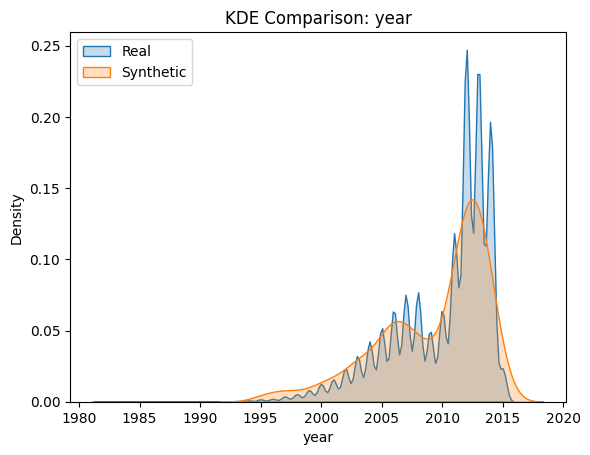

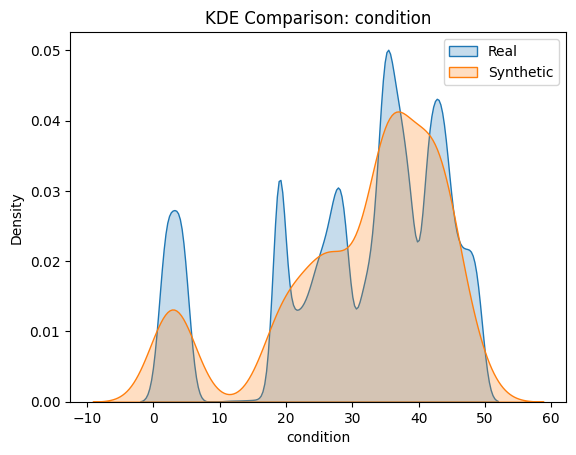

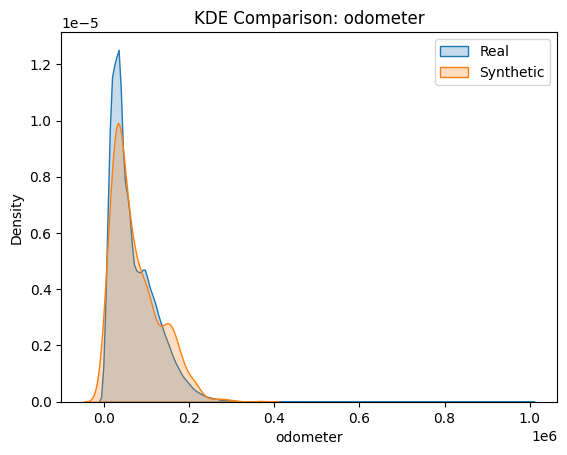

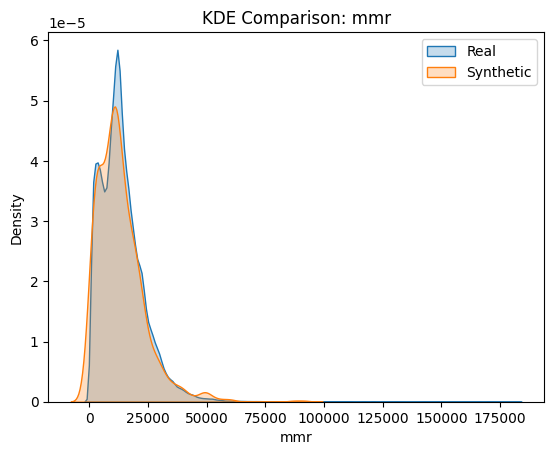

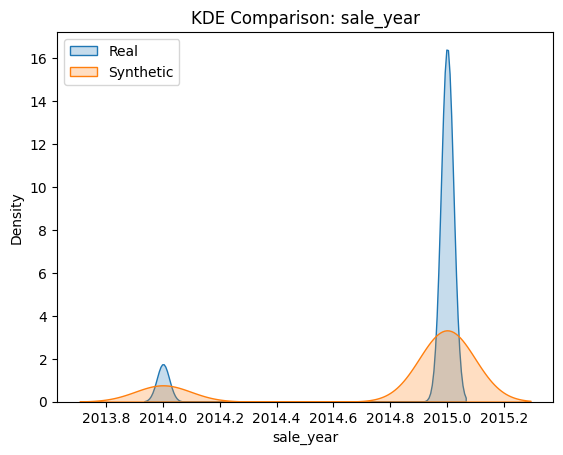

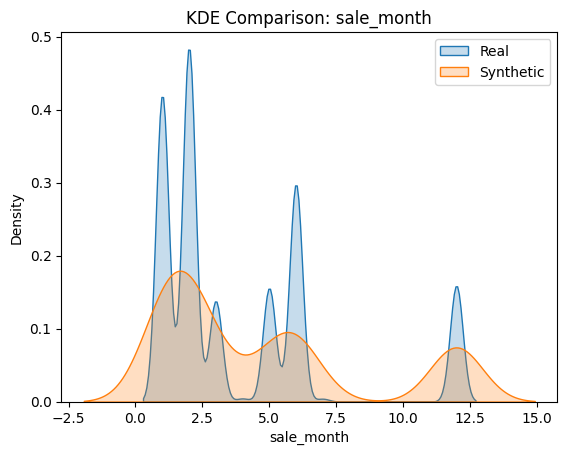

Running KS test...
       column   ks_stat       p_value
0        year  0.079484  6.236351e-06
1   condition  0.070707  8.767092e-05
2    odometer  0.059133  1.782553e-03
3         mmr  0.072607  5.078995e-05
4   sale_year  0.090104  1.682320e-07
5  sale_month  0.095105  2.622866e-08
Categorical comparison...


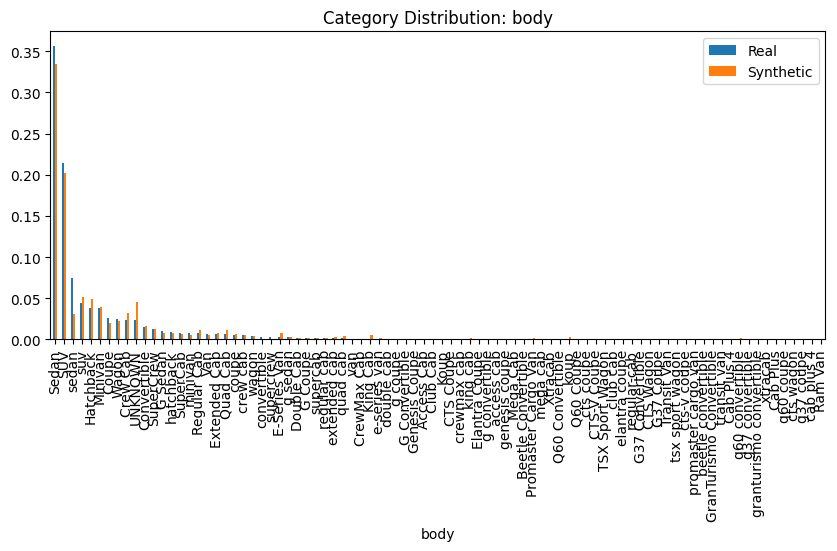

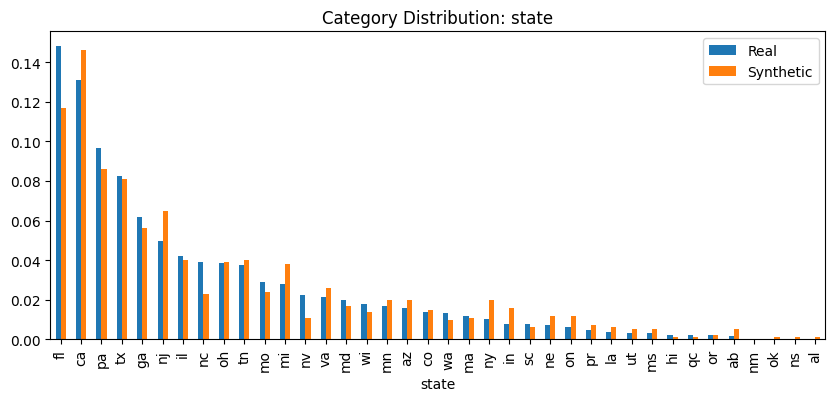

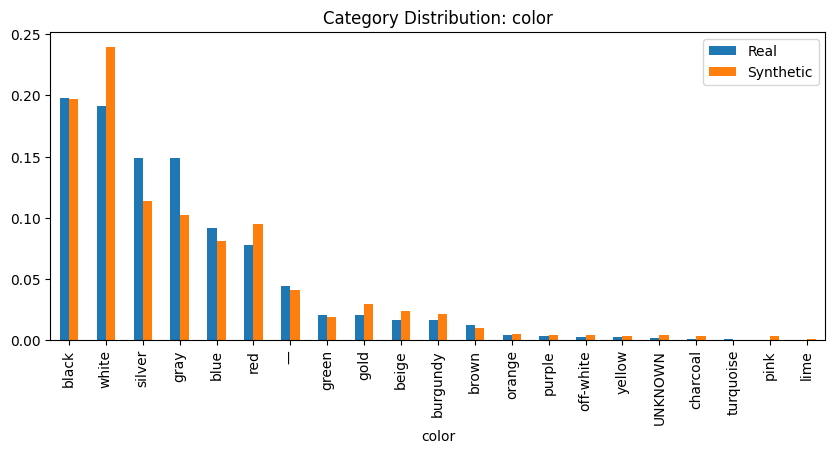

Correlation comparison...


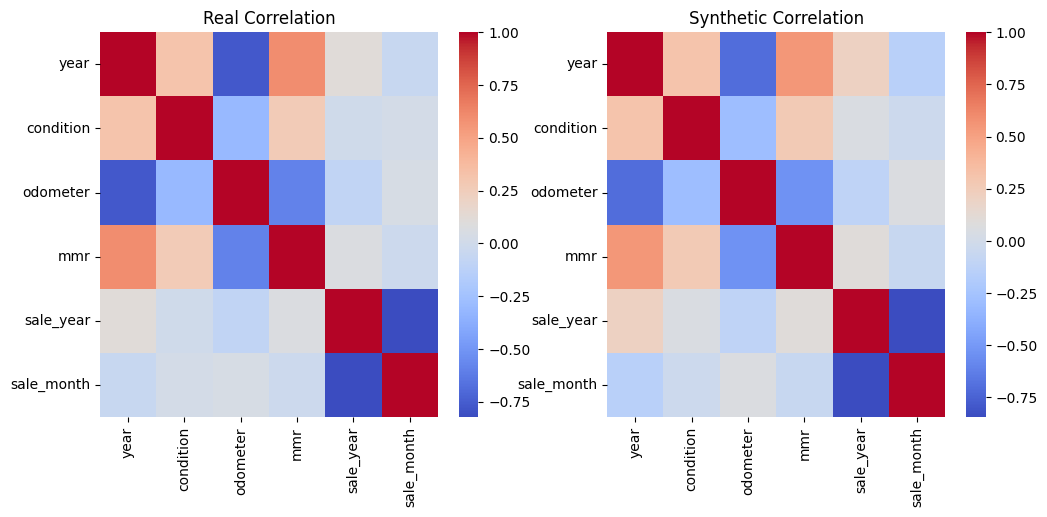

ML utility test...
ML Utility (R²): 0.8651


NameError: name 'y_true' is not defined

In [20]:
# INPUTS
real_df = vs_df.copy()
syn_df = synthetic_df.copy()  # your CTGAN output

target = "sellingprice"

numeric_cols = [
    "year", "condition", "odometer", "mmr", "sale_year", "sale_month"
]

categorical_cols = [
    "body", "state", "color"
]

# 1. KDE PLOTS (NUMERIC)
def plot_kde(real, syn, cols):
    for col in cols:
        plt.figure()
        sns.kdeplot(real[col], label="Real", fill=True)
        sns.kdeplot(syn[col], label="Synthetic", fill=True)
        plt.title(f"KDE Comparison: {col}")
        plt.legend()
        plt.show()

# 2. KS STATISTIC
def ks_test(real, syn, cols):
    results = []
    for col in cols:
        stat, pval = ks_2samp(real[col], syn[col])
        results.append((col, stat, pval))
    return pd.DataFrame(results, columns=["column", "ks_stat", "p_value"])


# 3. CATEGORICAL DISTRIBUTION
def categorical_comparison(real, syn, cols):
    for col in cols:
        real_dist = real[col].value_counts(normalize=True)
        syn_dist = syn[col].value_counts(normalize=True)

        df = pd.concat([real_dist, syn_dist], axis=1)
        df.columns = ["Real", "Synthetic"]
        df = df.fillna(0)

        df.plot(kind="bar", figsize=(10,4))
        plt.title(f"Category Distribution: {col}")
        plt.show()

# 4. CORRELATION COMPARISON
def correlation_comparison(real, syn, cols):
    real_corr = real[cols].corr()
    syn_corr = syn[cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    sns.heatmap(real_corr, ax=axes[0], cmap="coolwarm")
    axes[0].set_title("Real Correlation")

    sns.heatmap(syn_corr, ax=axes[1], cmap="coolwarm")
    axes[1].set_title("Synthetic Correlation")

    plt.show()

# 5. ML UTILITY TEST
# Train on synthetic → test on real
def ml_utility(real, syn, target):

    # One-hot encode
    real_enc = pd.get_dummies(real)
    syn_enc = pd.get_dummies(syn)

    # Align columns
    syn_enc = syn_enc.reindex(columns=real_enc.columns, fill_value=0)

    X_real = real_enc.drop(columns=[target])
    y_real = real_enc[target]

    X_syn = syn_enc.drop(columns=[target])
    y_syn = syn_enc[target]

    model = RandomForestRegressor(n_estimators=100, random_state=42)

    # Train on synthetic
    model.fit(X_syn, y_syn)

    # Test on real
    preds = model.predict(X_real)

    score = r2_score(y_real, preds)
    print(f"ML Utility (R²): {score:.4f}")

    rmse = mean_squared_error(y_real, y_pred, squared=False)
    print(f"ML Utility (RMSE): {rmse:.4f}")

# RUN TEST

print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

print("Running KS test...")
ks_results = ks_test(real_df, syn_df, numeric_cols)
print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target)

#Repeat for TVAE

In [ ]:
from ctgan import TVAE

tvae = TVAE(cuda=True)

In [ ]:
#Can be loaded to skip future preprocessing
vs_df = pd.read_csv(base_path+"/vehicle_sales_preprocessed.csv")

In [ ]:
tvae.fit(
    vs_df,
    discrete_columns = [
  "model",
  "body",
  "state",
  "color",
  "year_missing",
  "condition_missing",
  "odometer_missing",
  "mmr_missing",
  "sellingprice_missing",
  "sale_year",
  "sale_month",
  "sale_day",
  "sale_hour"
])


samples = tvae.sample(1000)

#Repeat for Diffusion Models

In [ ]:
from sdv.tabular import GaussianCopulaSynthesizer
from sdv.single_table import TVAESynthesizer  # or newer diffusion models if installed